In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 
from tqdm import tqdm
import cv2
import tifffile
from skimage.transform import resize

import os
import seaborn as sns
import tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

from keras.models import Sequential, Model
from keras.layers import Dense, Flatten, Conv2D, Reshape, Input, Conv2DTranspose
from keras.layers import Activation, LeakyReLU, BatchNormalization, Dropout, Resizing
from keras.losses import BinaryCrossentropy
from keras.applications import VGG16

import warnings
warnings.filterwarnings('ignore')

try:
    from tensorflow.keras.optimizers import Adam
except:
    from keras.optimizers import Adam

In [ ]:
NOISE_DIM = 100  
BATCH_SIZE = 4 
STEPS_PER_EPOCH = 100
EPOCHS = 1000
SEED = 40
WIDTH, HEIGHT, CHANNELS = 128, 128, 5

OPTIMIZER = Adam(0.0002, 0.5)

In [ ]:
MAIN_DIR = "./"

In [ ]:
def load_images(folder):
    imgs = []
    target = 1
    labels = []
    for i in os.listdir(folder):
        if i.endswith("_UNHEALTHY.tif"):
            img_dir = os.path.join(folder,i)
            try:
                img = tifffile.imread(img_dir)
                # Extract the first 3 channels (RGB)
                img = img[:,:,:]
                
                img = cv2.resize(img, (128,128))
                import sys
                import numpy
                numpy.set_printoptions(threshold=sys.maxsize)
                print(img)
                img = (img / 256).astype(np.uint8)
         
                
                imgs.append(img)
                labels.append(target)
            except:
                continue
                
    imgs = np.array(imgs)
    labels = np.array(labels)

    return imgs, labels

In [ ]:
data, labels = load_images(MAIN_DIR)
data.shape, labels.shape

In [ ]:
np.random.seed(SEED)
idxs = np.random.randint(0, 86, 20)

In [ ]:
X_train = data[idxs]
plt.figure(figsize=(20,8))
for i in range(10):
    axs = plt.subplot(2,5,i+1)
    plt.imshow(X_train[i][:,:,:3], cmap='gray', vmin=-1, vmax=1)
    plt.axis('off')
    axs.set_xticklabels([])
    axs.set_yticklabels([])
    plt.subplots_adjust(wspace=None, hspace=None)
plt.tight_layout()
X_train.shape
print(np.amin(X_train))


In [ ]:
# Normalize the Images
X_train = (X_train - X_train.min()) / (X_train.max() - X_train.min())

#print(X_train[0])
# Reshape images 
X_train = X_train.reshape(-1, WIDTH,HEIGHT,CHANNELS)
print(np.amax(X_train))
# Check shape
X_train.shape

plt.figure(figsize=(20,8))
for i in range(10):
    axs = plt.subplot(2,5,i+1)
    plt.imshow(X_train[i][:,:,:3], cmap='gray', vmin=-1, vmax=1)
    plt.axis('off')
    axs.set_xticklabels([])
    axs.set_yticklabels([])
    plt.subplots_adjust(wspace=None, hspace=None)
plt.tight_layout()

In [ ]:
def build_generator():

    """
        Generator model "generates" images using random noise. The random noise AKA Latent Vector
        is sampled from a Normal Distribution which is given as the input to the Generator. Using
        Transposed Convolution, the latent vector is transformed to produce an image
        We use 3 Conv2DTranspose layers (which help in producing an image using features; opposite
        of Convolutional Learning)

        Input: Random Noise / Latent Vector
        Output: Image
    """

    model = Sequential([

        Dense(32*32*256, input_dim=NOISE_DIM),
        LeakyReLU(alpha=0.2),
        Reshape((32,32,256)),
        
        Conv2DTranspose(128, (4, 4), strides=2, padding='same'),
        LeakyReLU(alpha=0.2),

        Conv2DTranspose(128, (4, 4), strides=2, padding='same'),
        LeakyReLU(alpha=0.2),

        Conv2D(CHANNELS, (4, 4), padding='same', activation='tanh')
    ], 
    name="generator")
    model.summary()
    model.compile(loss="binary_crossentropy", optimizer=OPTIMIZER)

    return model

In [ ]:
def build_discriminator():
    
    """
        Discriminator is the model which is responsible for classifying the generated images
        as fake or real. Our end goal is to create a Generator so powerful that the Discriminator
        is unable to classify real and fake images
        A simple Convolutional Neural Network with 2 Conv2D layers connected to a Dense output layer
        Output layer activation is Sigmoid since this is a Binary Classifier

        Input: Generated / Real Image
        Output: Validity of Image (Fake or Real)

    """

    model = Sequential([

        Conv2D(64, (3, 3), padding='same', input_shape=(WIDTH, HEIGHT, CHANNELS)),
        LeakyReLU(alpha=0.2),

        Conv2D(128, (3, 3), strides=2, padding='same'),
        LeakyReLU(alpha=0.2),

        Conv2D(128, (3, 3), strides=2, padding='same'),
        LeakyReLU(alpha=0.2),
        
        Conv2D(256, (3, 3), strides=2, padding='same'),
        LeakyReLU(alpha=0.2),
        
        Flatten(),
        Dropout(0.4),
        Dense(1, activation="sigmoid", input_shape=(WIDTH, HEIGHT, CHANNELS))
    ], name="discriminator")
    model.summary()
    model.compile(loss="binary_crossentropy",
                        optimizer=OPTIMIZER)

    return model

In [ ]:
print('\n')
discriminator = build_discriminator()
print('\n')
generator = build_generator()
trainable_discriminator_vars = discriminator.trainable_variables
trainable_generator_vars = generator.trainable_variables
trainable_vars = trainable_discriminator_vars + trainable_generator_vars
OPTIMIZER.build(trainable_vars)

discriminator.trainable = False 

gan_input = Input(shape=(NOISE_DIM,))
fake_image = generator(gan_input)

gan_output = discriminator(fake_image)

gan = Model(gan_input, gan_output, name="gan_model")
gan.compile(loss="binary_crossentropy", optimizer=OPTIMIZER)

print("The Combined Network:\n")
gan.summary()

In [36]:
def sample_images(noise, subplots, figsize=(22,8), save=False):
    generated_images = generator.predict(noise)
    plt.figure(figsize=figsize)
    #print(np.amax(generated_images))
    for i, image in enumerate(generated_images):
        plt.subplot(subplots[0], subplots[1], i+1)
        if CHANNELS == 1:
            plt.imshow(image.reshape((WIDTH, HEIGHT)), cmap='gray')    
                                                                            
        else:
            plt.imshow(image.reshape((WIDTH, HEIGHT, 3)))
            import matplotlib.image
            #print(np.amin(image.reshape((WIDTH, HEIGHT, 3))))
            from skimage import util
            image = (image - image.min()) / (image.max() - image.min())
            print(np.min(image))   # minimum value of the image data
            print(np.max(image))   # maximum value of the image data
            matplotlib.image.imsave('gen_img'+str(i)+'.png', image)
            tifffile.imwrite('gen_img'+str(i)+'.tiff', image.astype('float32'), shape=image.shape)

        if save == True:
            img_name = "gen" + str(i)
            plt.savefig(img_name)
        plt.subplots_adjust(wspace=None, hspace=None)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

1/1 [==============================] - 0s 95ms/step


  1%|          | 1/100 [00:00<01:14,  1.32it/s]

1/1 [==============================] - 0s 101ms/step


  2%|▏         | 2/100 [00:01<01:13,  1.34it/s]

...

1/1 [==============================] - 0s 95ms/step


100%|██████████| 100/100 [01:13<00:00,  1.36it/s]

EPOCH: 1 Generator Loss: 1.1935 Discriminator Loss: 0.6335
1/1 [==============================] - ETA: 0s

1/1 [==============================] - 0s 169ms/step


ValueError: cannot reshape array of size 81920 into shape (128,128,3)

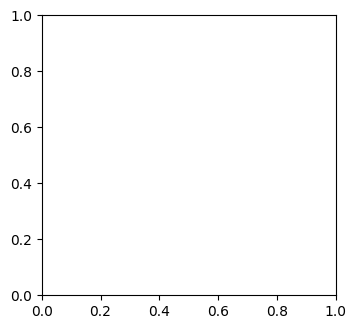

In [37]:
np.random.seed(SEED)
for epoch in range(10):
    for batch in tqdm(range(STEPS_PER_EPOCH)):

        noise = np.random.normal(0,1, size=(BATCH_SIZE, NOISE_DIM))
        fake_X = generator.predict(noise)
        
        idx = np.random.randint(0, X_train.shape[0], size=BATCH_SIZE)
        real_X = X_train[idx]

        X = np.concatenate((real_X, fake_X))

        disc_y = np.zeros(2*BATCH_SIZE)
        disc_y[:BATCH_SIZE] = 1

        d_loss = discriminator.train_on_batch(X, disc_y)
        
        y_gen = np.ones(BATCH_SIZE)
        g_loss = gan.train_on_batch(noise, y_gen)

    print(f"EPOCH: {epoch + 1} Generator Loss: {g_loss:.4f} Discriminator Loss: {d_loss:.4f}")
    noise = np.random.normal(0, 1, size=(10,NOISE_DIM))
    sample_images(noise, (2,5))

In [ ]:
noise = np.random.normal(0, 1, size=(100, NOISE_DIM))
sample_images(noise, (10,10), (24,20), save=True)

In [ ]:
!pip install --upgrade spectral

In [ ]:
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
import spectral
import rasterio

# Load the PNG image as a NumPy array
image_data = io.imread('gen_img73.png')


# Load the calibration coefficients for the sensor
# Replace these values with the actual calibration coefficients
calibration_coeffs = np.array([1.0, 2.0, 3.0, 4.0])

# Compute the radiance values from the digital numbers
radiance_data = image_data * calibration_coeffs

# Compute the reflectance values from the radiance values
# Replace these values with the actual calibration factors for your sensor
reflectance_factors = np.array([0.1, 0.2, 0.3, 0.4])
reflectance_data = radiance_data / reflectance_factors

# Create a Spectral image object from the reflectance data
spectral_image = spectral.Image(reflectance_data)

# Display the Spectral image object
spectral.imshow(spectral_image)

In [ ]:
pip install imagecodecs

In [ ]:
#from PIL import Image
#import numpy as np
#from matplotlib import pyplot as plt
#from PIL import Image
#import numpy as np

# Define calibration coefficients and atmospheric correction data
#D = 10.0  # Distance from camera to target (in meters)
#Lr = 10.0  # Radiance of calibration target (in W/m^2/sr/nm)
#Es = 100.0  # Spectral irradiance of light source (in W/m^2/nm)
#theta = 45.0  # Incidence angle of light (in degrees)
#S = 1000.0  # Sensor response (in counts)
#Ed = np.ones((128, 128, 3))  # Spectral radiance of observed object (in W/m^2/sr/nm)

# Load PNG image as NumPy array (assuming 3-band RGB image)
#img = np.array(Image.open('gen_img73.png').convert('RGB'))

# Convert pixel values to radiance units
#radiance_img = (img * Lr) / (Es * np.cos(np.deg2rad(theta)) * S)

# Calculate reflectance for each pixel
#R = (np.pi * D**2 * radiance_img) / (Es * np.cos(np.deg2rad(theta)) * S * np.pi * Ed)
#cmap = plt.cm.viridis

#norm = plt.Normalize(vmin=R.min(), vmax=R.max())
#colors = cmap(norm(R))
#colors = colors[:, :, :3]
#img = Image.fromarray((colors * 255).astype(np.uint8))
#img.save('reflectance.jpg')
import numpy as np
from tifffile import imread
from skimage.metrics import structural_similarity as ssim
from skimage import io
from skimage import io, exposure

import matplotlib.pyplot as plt
from skimage.transform import resize

import cv2


# Load two images
img1 = imread('imagem_segmentada_17_0830_LARGO2_UNHEALTHY.tif')
img1 = img1[:,:,:3]
# Resize the image to a new size
new_height, new_width = 128, 128
img1 = resize(img1, (new_height, new_width))
img1 = exposure.rescale_intensity(img1, in_range=(0, np.max(img1)), out_range=(0, 1))


img2 = io.imread('gen_img73.png')
img2 = img2[:,:,:3]
img2 = exposure.rescale_intensity(img2, in_range=(0, np.max(img2)), out_range=(0, 1))

# Compare the images using SSIM
ssim = ssim(img1, img2, data_range=1, full=True, channel_axis=2)
ssim_value = ssim[0]

# Display the comparison result in a bar chart
#plt.bar(['Image 1', 'Image 2'], [1-ssim_value, ssim_value])
#plt.title('SSIM Comparison')
#plt.xlabel('Images')
#plt.ylabel('SSIM Value')
#plt.show()

img1_array = img1.astype(np.uint8)
img2_array = img2.astype(np.uint8)

# Convert images to grayscale
print(img1.shape)
gray_img1 = cv2.cvtColor(img1.astype(np.float32), cv2.COLOR_BGR2HSV)
gray_img2 = cv2.cvtColor(img2.astype(np.float32), cv2.COLOR_BGR2HSV)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.imshow(gray_img1, cmap='gray')
ax1.set_title('Original Image')
ax2.imshow(gray_img2, cmap='gray')
ax2.set_title('Synthetic Image')
plt.show()

print(gray_img1.shape)
# Calculate histograms
hist1 = cv2.calcHist([gray_img1], [0], None, [255], [0, 255])
hist2 = cv2.calcHist([gray_img2], [0], None, [255], [0, 255])

# Normalize histograms
hist1 = cv2.normalize(hist1, hist1, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
hist2 = cv2.normalize(hist2, hist2, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

# Compare histograms using correlation
corr1 = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)
corr2 = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CHISQR)
corr3 = cv2.compareHist(hist1, hist2, cv2.HISTCMP_INTERSECT)
corr4 = cv2.compareHist(hist1, hist2, cv2.HISTCMP_BHATTACHARYYA)

# Plot histograms and correlation value
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

axs[0, 0].imshow(cv2.cvtColor(gray_img1, cv2.COLOR_BGR2RGB))
axs[0, 0].set_title('Original Image')

axs[0, 1].imshow(cv2.cvtColor(gray_img2, cv2.COLOR_BGR2RGB))
axs[0, 1].set_title('Synthetic Image')

axs[1, 0].plot(hist1, color='red')
axs[1, 0].set_title('Histogram 1')

axs[1, 1].plot(hist2, color='green')
axs[1, 1].set_title('Histogram 2')

fig.suptitle(f'Chi-square Corr: {corr2:.2f}; '+f'Intersect Corr: {corr3:.2f}; '+f'Bhattacharyya Corr: {corr4:.2f}')

plt.show()

print(corr2)
print(corr3)
print(corr4)

